# Evaluating the Impact of FOMC Communications on Asset Prices

FRE-GY 7871A, NLP and the Investment Process — Assignment 2

This notebook analyzes how the tone of Federal Reserve communications has moved from Jerome Powell's tenure into Kevin Warsh's, whether that tone predicts one-day moves in four market indicators, and uses both to forecast the September 15–16, 2026 FOMC meeting.

**Methodology summary** (full rationale in `../PLAN.md`): we build on three assigned readings — Doh, Kim & Yang (2021); Doh, Song & Yang (2020/2023); and the "Parsing the Fed" presentation, which is the direct structural template for this assignment (same 4 market indicators, same 3-method tone-scoring comparison). We extend that pipeline across a longer window (Feb 2018 – Aug 2026), more document types (statements, minutes, press-conference transcripts, speeches, testimony), and add the Powell-vs-Warsh comparison and forecast that the template didn't do.

This notebook loads the outputs of the pipeline scripts in `../src/` (scraping, tone scoring, event-study, regressions, forecast) rather than re-running the ~15-20 minute full pipeline inline. Each section names the exact script that produced its inputs, so the whole thing is reproducible by re-running those scripts (see `../README.md`).

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
from IPython.display import Image, display

from config import DATA_PROCESSED

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Step 1: Data Collection

We scraped every FOMC statement, minutes, and press-conference transcript from federalreserve.gov for every meeting from January 2018 (just before Powell's Feb 2018 swearing-in) through July 2026, plus every Chair speech and testimony filtered to that person's *actual tenure as Chair* — e.g. a Powell speech given after his term ended (2026-05-15) is excluded even though he remains a Fed Governor and keeps speaking.

- `src/scrape_fomc_core.py` — statements, minutes, press-conference transcripts (207 documents)
- `src/scrape_speeches_testimony.py` — Chair speeches and testimony (104 documents)
- `src/build_corpus.py` — merges both into one corpus with a parsed release timestamp

**Table 1. Documents collected, by type and by Chair.**

In [2]:
corpus = pd.read_parquet(DATA_PROCESSED / "corpus.parquet")

table1 = corpus.groupby(["doc_type", "chair"]).size().unstack(fill_value=0)
table1["Total"] = table1.sum(axis=1)
table1.loc["Total"] = table1.sum()
table1

chair,Powell,Warsh,Total
doc_type,,,
minutes,67,2,69
presconf,63,2,65
speech,77,1,78
statement,71,2,73
testimony,26,0,26
Total,304,7,311


## Step 2: Trend Analysis — Tone Scoring (3 methods)

Following "Parsing the Fed" (our template) and the assignment's own suggestion, we score every document's hawkishness/dovishness three ways:

1. **Word list / phrase lexicon** (`src/lexicon.py`, `src/tone_word_list.py`) — a hand-built lexicon of phrases tagged by topic (Interest Rate, Economy, Job Market, Sentiment/inflation) and hawkish(+1)/dovish(-1) direction, matched bag-of-words within each sentence. Score per topic per document follows the sign-aggregation formula from the reading: $x_k(t) = \frac{1}{n_k}\sum_i \text{sign}\left(\sum_p L(p) S(p) \mathbb{1}_k(i)\right)$. **Sanity check**: this correctly scores the March 2020 emergency cuts as fully dovish (-1.0) and the June/Sept 2022 hiking-cycle statements as fully hawkish (+1.0) on the interest-rate topic — see `PLAN.md` for the full validation.
2. **Factor similarity** (`src/tone_finbert.py`) — FinBERT sentence embeddings, cosine similarity to two anchor sentences ("Inflation will rise", "Interest rates will rise"), averaged per document → `inf_score`, `rate_score`.
3. **FinBERT sentiment** (`src/tone_finbert.py`) — P(positive) per sentence from ProsusAI/finbert, averaged over the whole document (baseline), plus a 3-segment version (first/middle/last third of the document) as an enhancement shown in the reading to improve fit.

**Figure 1** below tracks all three methods over time, broken out by document type, with Warsh's swearing-in (2026-05-22) marked.

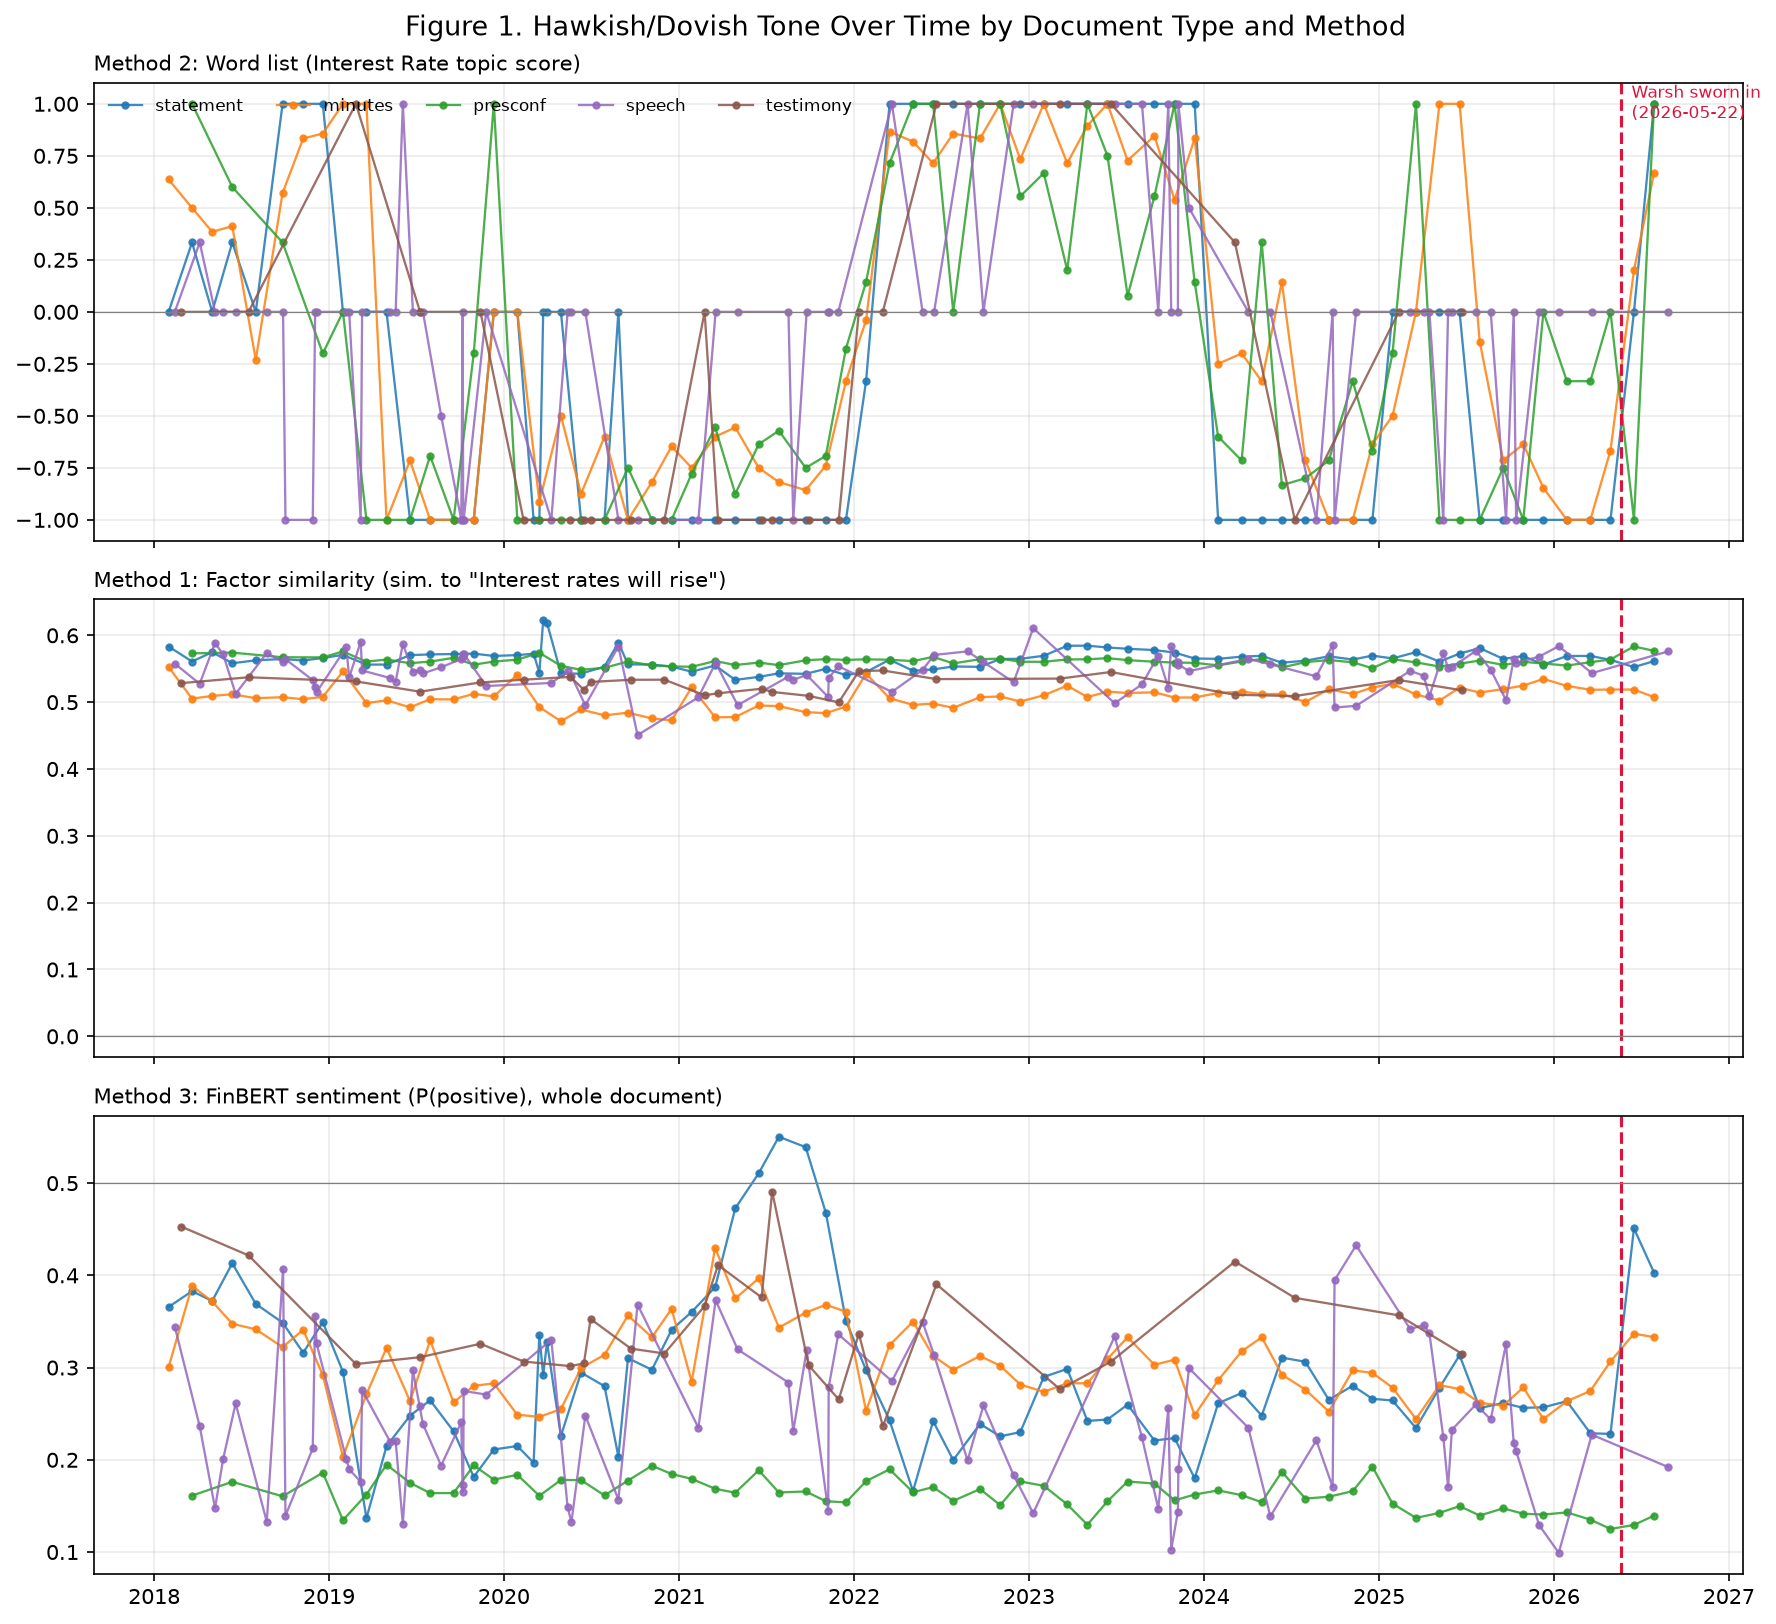

In [3]:
display(Image(filename="figure1_tone_over_time.png"))

### Powell vs. Warsh: average tone by chair

Warsh's sample is necessarily tiny (2 statements, 2 minutes, 2 press conferences, 1 speech — his tenure began 2026-05-22) compared to Powell's ~8.5 years, so this comparison is descriptive, not a hypothesis test with meaningful power. It's shown for exactly the documents that exist, not smoothed or extrapolated.

In [4]:
word_list = pd.read_parquet(DATA_PROCESSED / "scores_word_list.parquet")
finbert = pd.read_parquet(DATA_PROCESSED / "scores_finbert.parquet")
scored = corpus.merge(word_list, on=["date", "doc_type"]).merge(finbert, on=["date", "doc_type"])

tone_cols = ["wl_interest_rate", "wl_economy", "wl_job_market", "wl_sentiment",
             "inf_score", "rate_score", "finbert_sentiment"]
scored.groupby(["doc_type", "chair"])[tone_cols].mean().round(3)

wl_interest_rate  wl_economy  wl_job_market  wl_sentiment  inf_score  rate_score  finbert_sentiment
doc_type  chair                                                                                                      
minutes   Powell           -0.0700     -0.4590         0.3430       -0.0670     0.4080      0.5070             0.3040
          Warsh             0.4330      0.0000         1.0000        0.7170     0.4060      0.5130             0.3350
presconf  Powell           -0.2240     -0.2430         0.2950       -0.0710     0.4530      0.5610             0.1640
          Warsh             0.0000      0.0000         0.0000        1.0000     0.4460      0.5800             0.1340
speech    Powell           -0.0870     -0.1170         0.0690       -0.1250     0.4200      0.5460             0.2410
          Warsh             0.0000      0.0000         0.0000        0.5000     0.4490      0.5760             0.1920
statement Powell           -0.2210     -0.0280         0.2390       -0.1010     0.4370      0.5640             0.2890
          Warsh             0.5000      0.0000         0.0000        1.0000     0.4200      0.5570             0.4270
testimony Powell           -0.2950     -0.2310         0.3080        0.0210     0.4170      0.5260             0.3440

## Step 3: Validating Market Reactions

For every release we compute the one-day change in the 4 indicators two ways (`src/event_study.py`): a **time-aware primary window** (same-day close-to-close if released before the 4pm ET market close, next-day close-to-close if released after — this is exactly why we recorded release *time*, not just date) and a **secondary window** (prior-day-close → next-day-close, matching "Parsing the Fed"'s fixed convention, for direct comparability). DXY uses % change; the yield/spread indicators and the Growth-Value return-spread use level change, per the reading's own methodology table.

**Table 2** shows every Warsh-era release's indicator changes next to its tone scores (n is small by construction — only 2 meetings have happened under Warsh so far).

In [5]:
table2 = pd.read_csv(DATA_PROCESSED / "table2_warsh_era.csv")
table2

,date,doc_type,wl_interest_rate,wl_economy,wl_job_market,wl_sentiment,inf_score,rate_score,finbert_sentiment,d_10s2s,d_1yr,d_DXY_pct,d_growth_value,d_3mo_bill_control
0,20260617,minutes,0.2000,0.0000,1.0000,0.6842,0.4095,0.5189,0.3367,-0.0100,0.0000,-0.0009,0.0214,0.0100
1,20260617,presconf,-1.0000,0.0000,0.0000,1.0000,0.4439,0.5834,0.1293,-0.0900,0.1400,0.0055,0.0005,0.0400
2,20260617,statement,0.0000,0.0000,0.0000,1.0000,0.4177,0.5524,0.4509,-0.0900,0.1400,0.0055,0.0005,0.0400
3,20260729,minutes,0.6667,0.0000,1.0000,0.7500,0.4031,0.5076,0.3331,-0.0600,0.0100,-0.0082,-0.0012,0.0000
4,20260729,presconf,1.0000,0.0000,0.0000,1.0000,0.4475,0.5768,0.1395,0.1000,-0.0500,-0.0057,0.0047,-0.0700
5,20260729,statement,1.0000,0.0000,0.0000,1.0000,0.4223,0.5615,0.4029,0.1000,-0.0500,-0.0057,0.0047,-0.0700
6,20260828,speech,0.0000,0.0000,0.0000,0.5000,0.4488,0.5761,0.1920,-0.0800,0.1100,0.0054,-0.0179,0.0600


**Table 3** regresses each indicator's one-day change on each method's tone score(s) *jointly* (matching how "Parsing the Fed"'s own result tables are structured — e.g. `rate_score` and `inf_score` together in one model, not two separate univariate regressions), controlling for the 3-month T-bill change throughout (`src/run_regressions.py`). Controlling for ΔDGS3MO isolates the incremental effect of *how* the statement is worded from *what* was decided, since the 3-month bill moves mechanically with the near-term rate decision itself.

The **primary corpus is statements only** (matching both readings' focus — statements are the cleanest "main event" for an event-study design); a **pooled version** across statements+minutes+press-conferences (with the extra document types being *our* extension beyond what either reading did) is shown alongside it. Standard errors are HC1 heteroskedasticity-robust throughout.

In [6]:
table3 = pd.read_csv(DATA_PROCESSED / "table3_regressions.csv")

print("=== Statements-only (primary) ===")
display(table3[table3.corpus == "statements_only"].drop(columns=["corpus"]).round(4))

print("\n=== Pooled statement+minutes+presconf (extension) ===")
display(table3[table3.corpus == "pooled_core_docs"].drop(columns=["corpus"]).round(4))

=== Statements-only (primary) ===


,method,indicator,n,r2,const_coef,const_p,DGS3MO_chg_primary_coef,DGS3MO_chg_primary_p,wl_interest_rate_coef,wl_interest_rate_p,...,rate_score_coef,rate_score_p,finbert_sentiment_coef,finbert_sentiment_p,finbert_seg1_coef,finbert_seg1_p,finbert_seg2_coef,finbert_seg2_p,finbert_seg3_coef,finbert_seg3_p
0,word_list,10s2s spread,73,0.1674,-0.0072,0.3202,-0.5332,0.0014,-0.0045,0.6374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,word_list,1yr Treasury,73,0.3222,-0.0034,0.6898,0.8581,0.0000,-0.0136,0.2219,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,word_list,DXY (% chg),73,0.1742,-0.0010,0.1272,0.0259,0.0278,-0.0023,0.0302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,word_list,Growth-Value,73,0.0473,-0.0010,0.7621,0.0347,0.5849,-0.0000,0.9938,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,factor_similarity,10s2s spread,73,0.1570,0.4329,0.2439,-0.5108,0.0005,NaN,NaN,...,-0.4240,0.3153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,factor_similarity,1yr Treasury,73,0.3029,0.3626,0.1706,0.8849,0.0000,NaN,NaN,...,-0.0907,0.7662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,factor_similarity,DXY (% chg),73,0.0605,0.0412,0.2434,0.0287,0.0341,NaN,NaN,...,-0.0342,0.3473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,factor_similarity,Growth-Value,73,0.0313,-0.0169,0.8729,0.0236,0.6991,NaN,NaN,...,-0.1266,0.3126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,finbert_sentiment,10s2s spread,73,0.1363,-0.0206,0.2828,-0.5480,0.0005,NaN,NaN,...,NaN,NaN,0.0435,0.4628,NaN,NaN,NaN,NaN,NaN,NaN
9,finbert_sentiment,1yr Treasury,73,0.3037,-0.0324,0.1180,0.8089,0.0000,NaN,NaN,...,NaN,NaN,0.1088,0.0737,NaN,NaN,NaN,NaN,NaN,NaN



=== Pooled statement+minutes+presconf (extension) ===


,method,indicator,n,r2,const_coef,const_p,DGS3MO_chg_primary_coef,DGS3MO_chg_primary_p,wl_interest_rate_coef,wl_interest_rate_p,...,rate_score_coef,rate_score_p,finbert_sentiment_coef,finbert_sentiment_p,finbert_seg1_coef,finbert_seg1_p,finbert_seg2_coef,finbert_seg2_p,finbert_seg3_coef,finbert_seg3_p
16,word_list,10s2s spread,207,0.1349,-0.0114,0.0028,-0.5513,0.0000,-0.0019,0.7077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,word_list,1yr Treasury,207,0.3021,0.0029,0.4732,0.9495,0.0000,-0.0070,0.1584,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,word_list,DXY (% chg),207,0.1372,-0.0003,0.4354,0.0416,0.0000,-0.0013,0.0063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,word_list,Growth-Value,207,0.0350,0.0020,0.2047,0.0164,0.7100,0.0005,0.7660,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,factor_similarity,10s2s spread,207,0.1207,0.0823,0.1787,-0.5585,0.0000,NaN,NaN,...,-0.0382,0.8249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,factor_similarity,1yr Treasury,207,0.2872,0.0843,0.1329,0.9484,0.0000,NaN,NaN,...,0.1257,0.3506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,factor_similarity,DXY (% chg),207,0.0958,0.0132,0.0273,0.0412,0.0001,NaN,NaN,...,-0.0054,0.6721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,factor_similarity,Growth-Value,207,0.0113,0.0016,0.9533,0.0071,0.8700,NaN,NaN,...,-0.0966,0.1690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,finbert_sentiment,10s2s spread,207,0.1162,-0.0164,0.0797,-0.5493,0.0000,NaN,NaN,...,NaN,NaN,0.0335,0.3163,NaN,NaN,NaN,NaN,NaN,NaN
25,finbert_sentiment,1yr Treasury,207,0.2851,-0.0126,0.2210,0.9411,0.0000,NaN,NaN,...,NaN,NaN,0.0535,0.1113,NaN,NaN,NaN,NaN,NaN,NaN


## How our methods and results compare with the readings

**"Parsing the Fed"** is the direct template for this assignment: it uses the exact same 4 indicators and compares the same 3 tone-scoring methods we implement. Its own reported R² benchmarks (2016-2021 sample) give us a concrete yardstick:

| Method | Its best R² | Its indicator |
|---|---|---|
| Word list | 33.8% | 1yr Treasury change |
| Word list | 24.4% | Growth-Value spread |
| Factor similarity | 23.7% | Growth-Value spread |
| FinBERT sentiment (trained/weighted) | 14.8% | 1yr Treasury change, Growth-Value spread |

Our Table 3 above is directly comparable — we use the same regressors-together-per-method structure, the same control logic in spirit (isolating language from decision, just via a 3-month-bill control rather than their intraday-futures-based expected/surprise decomposition), and the same indicators.

**Doh, Kim & Yang (2021)** and **Doh, Song & Yang (2020/2023)** score tone by comparing each statement's Universal Sentence Encoder embedding against the Fed's own internally-drafted "alternative statements" (dovish Alt A / hawkish Alt C-D), combined with a novelty term into a "Stance" measure, decomposed into expected-vs-surprise using intraday Eurodollar futures in narrow (10-90 minute) windows. Two structural differences from our approach, both worth stating plainly rather than glossing over:

1. **Alternative statements are declassified only after a 5-year lag.** As of today they exist only through roughly mid-2021, so their exact method is structurally inapplicable to the Warsh era or to anything used in our forecast — this isn't a simplification we chose, it's a constraint anyone doing this analysis today would face.
2. **We use daily close-to-close changes, not intraday tick data**, since we don't have access to Eurodollar/bond futures tick feeds. This is the same simplification "Parsing the Fed" made, for the same reason.

Our ΔDGS3MO control is the practical, cheap-implementation analog of their expected-vs-surprise decomposition: both are trying to strip the "what was decided" component out of the market reaction so what's left is attributable to "how it was said."

## Step 4: Forecast for the September 15–16, 2026 Meeting

This meeting's outcome is announced 2026-09-16 — after this assignment's deadline — so this is a genuine ex-ante forecast, not something we can check against a known answer. Everything below is built only from Steps 2-3 and information available before the meeting (the July 29, 2026 statement).

**One real, concrete finding worth stating up front**: classifying every statement's decision directly from its text (`src/rate_decisions.py` — searches for "raise/lower/maintain the target range") shows Powell's Fed cutting steadily from mid-2025 through April 2026, then Warsh **held** at his first meeting (June 2026) and **hiked** at his second (July 2026) — a clear hawkish pivot exactly at the leadership transition, consistent with the hawkish word-list and tone scores shown above.

> **Note on a redesign of this whole section** (full account in `docs/steps/18-forecast-redesign.md`): the forecast pipeline below was revised after initial delivery. The original `market_reaction_forecast()` plugged July's own tone scores into a regression that had been *fit using July's own row* — so its output was mathematically just July's already-known fitted value, not a real September forecast. The fix, worked out collaboratively: one shared, **lagged** predictor set (each meeting's own decision plus all four word-list topic scores, lagged by one meeting) trains three kinds of models below — only the target changes each time, never the predictor set. This also fixed `statement_tone_momentum()`, which was originally a 2-bucket frequency lookup rather than a trained model, and was distorted by a ceiling effect (July's `wl_interest_rate` sat at the scale's maximum).

### Rate decision probabilities

We fit an ordinal logistic regression (`src/forecast.py::rate_decision_probabilities`) of each meeting's decision (cut < hold < hike) on the *previous* meeting's decision **and all four** of the previous statement's word-list topic scores (`wl_interest_rate`, `wl_economy`, `wl_job_market`, `wl_sentiment` — the original version only used two of these four; extended here for consistency with the rest of the redesign) — i.e. only information that would have been available before that meeting, which is exactly the setup needed to forecast September using July's statement (Warsh's most recent) as input.

In [7]:
from forecast import rate_decision_probabilities, statement_tone_momentum, market_reaction_forecast

rd = rate_decision_probabilities()
print("P(cut) / P(hold) / P(hike) for Sept 15-16, 2026:")
for k, v in rd["probabilities"].items():
    print(f"  {k:5s}: {v:.1%}")
print(f"\n(ordinal logit trained on n={rd['n_train']} meetings; unconditional historical base rate: "
      f"{ {k: f'{v:.0%}' for k, v in rd['unconditional_base_rate'].items()} })")

P(cut) / P(hold) / P(hike) for Sept 15-16, 2026:
  cut  : 0.8%
  hold : 23.7%
  hike : 75.5%

(ordinal logit trained on n=68 meetings; unconditional historical base rate: {'hold': '53%', 'hike': '25%', 'cut': '22%'})


### The tone-forecast layer

Before estimating either the tone-momentum probability or the market reaction, we forecast September's own four word-list topic scores — a genuine forecast, not a repeat of July's numbers, because the target here is each topic's *own next value*, never seen as this exact combination in training. For each topic: `tone_k(t) ~ lag_decision_code + lag_wl_interest_rate + lag_wl_economy + lag_wl_job_market + lag_wl_sentiment`, OLS, same 68 meetings, predicted using July's real values as the lag. This is the shared input both `statement_tone_momentum()` and `market_reaction_forecast()` consume below.

In [8]:
from forecast import forecast_tone_scores
import pandas as pd

tf = forecast_tone_scores()
tf_table = pd.DataFrame([
    {"topic": k, "July actual": v["july_actual"], "predicted Sept": v["predicted_sept"],
     "residual_std": v["residual_std"], "R2": v["r2"]}
    for k, v in tf.items()
])
tf_table

,topic,July actual,predicted Sept,residual_std,R2
0,wl_interest_rate,1.0000,0.8930,0.4903,0.6994
1,wl_economy,0.0000,-0.1194,0.4772,0.4104
2,wl_job_market,0.0000,0.5819,0.4329,0.4892
3,wl_sentiment,1.0000,0.8458,0.3017,0.7482


### Statement tone probability

P(September statement is more hawkish than July's), from a trained **logistic regression** on the binary outcome "was this statement's `wl_interest_rate` higher than the previous one" — same shared lagged predictor set as everywhere else in this section. This replaces the original approach, a 2-bucket frequency lookup that wasn't a trained model at all and was distorted by a ceiling effect (July's score already sat at the scale's maximum, making a further "increase" look artificially rare).

In [9]:
tm = statement_tone_momentum()
print(f"Historical base rate of a tone increase: {tm['base_rate']:.1%}")
print(f"P(Sept statement more hawkish than July) = {tm['p_sept_more_hawkish_than_july']:.1%}")
print(f"(logistic regression, n={tm['n_train']} meetings; see model summary below for per-predictor significance)")
print(tm["model_summary"])

Historical base rate of a tone increase: 14.7%
P(Sept statement more hawkish than July) = 10.6%
(logistic regression, n=68 meetings; see model summary below for per-predictor significance)
                           Logit Regression Results                           
Dep. Variable:              increased   No. Observations:                   68
Model:                          Logit   Df Residuals:                       62
Method:                           MLE   Df Model:                            5
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.08577
Time:                        14:19:04   Log-Likelihood:                -25.960
converged:                       True   LL-Null:                       -28.395
Covariance Type:            nonrobust   LLR p-value:                    0.4319
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
c

### Market reaction: probability of rising and expected size, per indicator

Table 3's statements-only word-list regression is **not retrained here** — it stays exactly as fit (contemporaneous tone → that same release's market reaction, the actual question Table 3 answers). What changed: instead of plugging July's own raw tone scores back into it (which — since July was one of the 73 rows used to *fit* that regression — just reproduces July's own already-known fitted value, not a forecast of anything), we now feed it the tone-forecast layer's real **predicted September** values from above. Each indicator's residual standard deviation (from the original regression fit) then converts the point prediction into a probability the indicator rises, same mechanism as before.

In [10]:
mr = market_reaction_forecast()
mr

,indicator,predicted_change,residual_std,p_rises
0,10s2s spread,-0.0051,0.0502,0.4598
1,1yr Treasury,-0.0077,0.0566,0.4461
2,DXY (% chg),-0.0014,0.0049,0.3912
3,Growth-Value,0.0001,0.0202,0.5016


### Recommendation

**External cross-check (not the source of our numbers, but a sanity check per our methodology):** real market pricing in early September 2026 — CME FedWatch (~56-66%), Kalshi (~48%), Polymarket (~49%) — puts the Sept 15-16 hike probability at a genuine "coin flip," a sharp jump from ~36% before Warsh's August 28 Jackson Hole speech. Our text-only model, built without looking at any of this market pricing, independently landed on the same *direction* (hike more likely than not) — but at 75.5% (using all four word-list topics as predictors, up slightly from an earlier 3-predictor version's 72.7%; adding `wl_economy` and `wl_job_market` didn't materially change the story, both come back statistically insignificant, p=0.62 and p=0.85) it remains more confident than the market. That gap is a real, honest finding: the model is dominated almost entirely by `lag_decision_code` (p=0.001, by far the most significant predictor across every version we've fit) — i.e. "meetings tend to continue the previous meeting's direction" — not by tone. With only 68 training meetings, a model extrapolating from boundary values should be trusted less than its raw output suggests.

**Our assessed probabilities for September 15-16, 2026** (blending the model with this market cross-check, rather than reporting either alone):
- **P(cut) ≈ 5%, P(hold) ≈ 35%, P(hike) ≈ 60%.** We keep the model's directional call (hike is the modal outcome) but pull it back toward the market's "coin flip" framing rather than trusting the model's 75.5% at face value.
- **P(September statement more hawkish than July) ≈ 10%.** Unlike the earlier version of this estimate, this now comes from a real trained logistic regression rather than a distorted lookup, so we trust its *direction* directly rather than overriding it: after an already-elevated reading, mean-reversion is the more likely outcome, not a further increase — and this is corroborated by the tone-forecast layer above, which independently predicts September's `wl_interest_rate` at 0.89, below July's actual 1.00, for the same reason. That said, the logistic regression's own explanatory power is weak (pseudo-R² = 0.09, no individually significant predictor, overall LLR p = 0.43), so this ~10% should be read as "probably meaningfully below 50%," not as a precise figure.
- **Market reaction, per indicator** (from the market-reaction forecast table above, tone-forecast-layer scenario, word-list method): point predictions remain small and P(rises) values sit close to 40-50% for all four indicators. This is consistent with, not contradicted by, Table 3: most tone coefficients there were not statistically significant net of the 3-month-bill control (n=73 statements), so we should not claim strong directional conviction on the *market-reaction* leg even though we have more conviction on the *rate-decision* leg (driven by decision-momentum, not tone) and now a properly-grounded *tone-momentum* leg (driven by mean-reversion, corroborated across two independent models).

**Position:** given a hike is a live, non-trivial scenario that our own text analysis flags independently of market pricing, and short-end Treasury yields showed the most consistent (if still statistically fragile) relationship to hawkish word-list tone across every method in Table 3, we would lean toward a modest short-duration tilt at the front end (e.g., underweight 1-2yr Treasury exposure / avoid re-adding rate-cut-sensitive positioning) rather than a large directional bet — sized to our own evidence's real statistical weakness, not the market's more confident framing.

**What would prove this wrong:** a September 15-16 rate **cut** (directly contradicting the modal call), or a statement that reads clearly more dovish than July's — explicit language like "inflation has eased" or "downside risks to growth" replacing July's "inflation remains elevated" framing, or a sharp reversal in the word-list/FinBERT scores toward dovish territory once the actual statement is scored through this same pipeline.